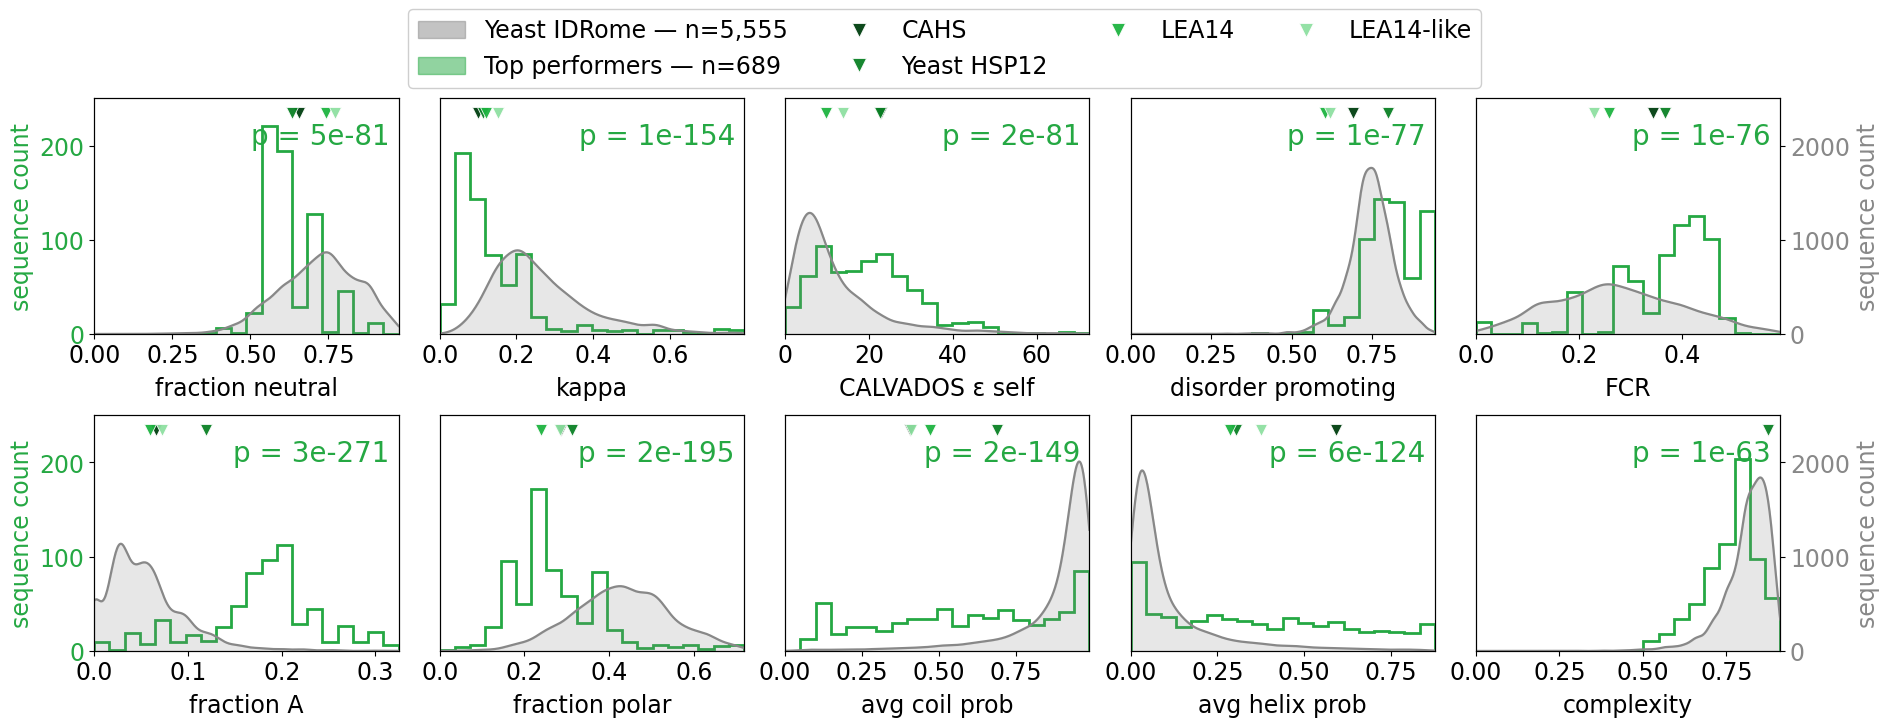

In [1]:
"""
top_performers_vs_yeast_IDRome_subset.py

Dual-axis comparison of key features:
  Left  y-axis (green) — top performers, raw counts
  Right y-axis (gray)  — yeast IDRome, KDE scaled to count units
"""

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
SEQ_PATH    = '/Users/khunt/Downloads/sequencing_data_all.csv'
MERGED_PATH = '/Users/khunt/Desktop/Projects/emenecker_guadalupe_2023/Data/Figure_5/IDRome_and_indiv_features.csv'

# ── Parameters ────────────────────────────────────────────────────────────────
PADJ_CUTOFF     = 0.05
FDR_ALPHA       = 0.05
EFFECT_SIZE_MIN = 0.1
N_BINS          = 20
NCOLS           = 5
PERCENTILE_CLIP = 99

# ── Features ──────────────────────────────────────────────────────────────────
FEATURES = [
    ('cider_fraction_neutral',         'fraction neutral'),
    ('cider_kappa',                    'kappa'),
    ('finches_calvados_epsilon_self',  'CALVADOS ε self'),
    ('nardini_Disorder Promoting_raw', 'disorder promoting'),
    ('nardini_FCR_raw',                'FCR'),
    ('nardini_Frac A_raw',             'fraction A'),
    ('nardini_Frac Polar_raw',         'fraction polar'),
    ('sparrow_avg_coil_prob',          'avg coil prob'),
    ('sparrow_avg_helix_prob',         'avg helix prob'),
    ('sparrow_complexity',             'complexity'),
]

XMAX_OVERRIDE  = {'finches_calvados_epsilon_self': 100}
INDIV_NAME_COL = 'Name'
INDIV_KEEP_MAP = {
    'CAHS_106094': 'CAHS',
    'HSP12_yeast': 'Yeast HSP12',
    'O03983':      'LEA14',
    'O02355':      'LEA14-like',
}
INDIV_KEEP   = list(INDIV_KEEP_MAP.keys())
INDIV_COLORS = {
    'CAHS_106094': '#003F0F',
    'HSP12_yeast': '#0A8125',
    'O03983':      '#1DB340',
    'O02355':      '#8EE0A1',
}
C_YEAST = '#888888'
C_TOP   = '#25A843'

FS_TITLE  = 17
FS_YLABEL = 17
FS_YTICK  = 17
FS_XTICK  = 17
FS_STARS  = 20
FS_LEGEND = 17

# ── Stat helpers ──────────────────────────────────────────────────────────────
def bh_correct(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n     = len(pvals)
    order = np.argsort(pvals)
    ranked = np.empty(n); ranked[order] = np.arange(1, n + 1)
    adj = np.minimum(1.0, pvals * n / ranked)
    adj = np.minimum.accumulate(adj[order][::-1])[::-1]
    result = np.empty(n); result[order] = adj
    return result

def mwu_effect(a, b):
    if len(a) < 2 or len(b) < 2: return 1.0, 0.0
    U, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    return p, 1.0 - (2.0 * U) / (len(a) * len(b))

# ── Load ──────────────────────────────────────────────────────────────────────
merged = pd.read_csv(MERGED_PATH)
yeast  = merged[merged['source'] == 'yeast_IDRome'].copy().reset_index(drop=True)
indiv  = (merged[merged['source'] == 'individual']
            .pipe(lambda d: d[d[INDIV_NAME_COL].isin(INDIV_KEEP)])
            .assign(_o=lambda d: d[INDIV_NAME_COL].map({n: i for i, n in enumerate(INDIV_KEEP)}))
            .sort_values('_o').drop(columns='_o').reset_index(drop=True))

# ── Weighted LFC ──────────────────────────────────────────────────────────────
seq = pd.read_csv(SEQ_PATH).copy()
w_num, w_den = np.zeros(len(seq)), np.zeros(len(seq))
for lc, sc in zip(['log2FoldChange_rep1','log2FoldChange_rep2','log2FoldChange_rep3'],
                  ['lfcSE_rep1','lfcSE_rep2','lfcSE_rep3']):
    lfc, se = seq[lc].values, seq[sc].values
    w = np.where((se > 0) & np.isfinite(se) & np.isfinite(lfc), 1/se**2, 0.)
    w_num += w * np.nan_to_num(lfc); w_den += w
seq['weighted_lfc'] = np.where(w_den > 0, w_num / w_den, np.nan)
seq['any_sig'] = ((seq['padj_rep1'] < PADJ_CUTOFF) |
                  (seq['padj_rep2'] < PADJ_CUTOFF) |
                  (seq['padj_rep3'] < PADJ_CUTOFF))
top = seq[seq['any_sig'] & (seq['weighted_lfc'] > 0)].copy()

# ── Precompute stats ───────────────────────────────────────────────────────────
cols = [f[0] for f in FEATURES]
p_raw, r_all, valid_data = [], [], {}

for col in cols:
    y = yeast[col].dropna().values if col in yeast.columns else np.array([])
    t = top[col].dropna().values   if col in top.columns   else np.array([])
    y = y[np.isfinite(y) & (y >= 0)]
    t = t[np.isfinite(t) & (t >= 0)]
    combined = np.concatenate([y, t])
    hi = np.percentile(combined, PERCENTILE_CLIP) if len(combined) else 1.0
    hi = min(hi, XMAX_OVERRIDE.get(col, hi))
    y  = y[y <= hi]; t = t[t <= hi]
    valid_data[col] = (y, t, 0.0, hi)
    p, r = mwu_effect(t, y)
    p_raw.append(p); r_all.append(r)

adj    = bh_correct(p_raw)
cstats = {col: (adj[i], r_all[i]) for i, col in enumerate(cols)}

# ── Plot ──────────────────────────────────────────────────────────────────────
nrows     = int(np.ceil(len(FEATURES) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS, figsize=(NCOLS * 3.8, nrows * 3.6))
axes_flat = axes.flatten() if nrows > 1 else list(axes)
fig.patch.set_facecolor('white')

rightmost_indices = {min(i * NCOLS + NCOLS - 1, len(FEATURES) - 1) for i in range(nrows)}

for idx, (col, label) in enumerate(FEATURES):
    ax_l = axes_flat[idx]
    ax_r = ax_l.twinx()

    y_vals, t_vals, lo, hi = valid_data[col]
    bins         = np.linspace(lo, hi, N_BINS + 1)
    is_rightmost = idx in rightmost_indices
    is_leftmost  = (idx % NCOLS == 0)

    # Yeast IDRome KDE — right axis
    if len(y_vals) > 1 and np.std(y_vals) > 0:
        x_kde = np.linspace(lo, hi, 400)
        yk    = stats.gaussian_kde(y_vals, bw_method='scott')(x_kde) * len(y_vals) * (hi - lo) / N_BINS
        ax_r.fill_between(x_kde, yk, alpha=0.20, color=C_YEAST, zorder=1)
        ax_r.plot(x_kde, yk, color=C_YEAST, lw=1.6, zorder=2)
    ax_r.set_ylim(0, 2500)
    ax_r.spines['top'].set_visible(True)
    if is_rightmost:
        ax_r.set_ylabel('sequence count', fontsize=FS_YLABEL, color=C_YEAST)
        ax_r.tick_params(axis='y', labelsize=FS_YTICK, labelcolor=C_YEAST)
    else:
        ax_r.set_ylabel(''); ax_r.tick_params(axis='y', labelsize=0, length=0)
        ax_r.set_yticklabels([])

    # Top performers histogram — left axis
    if len(t_vals) > 1 and np.std(t_vals) > 0:
        ct, edges = np.histogram(t_vals, bins=bins)
        ax_l.stairs(ct, edges, color=C_TOP, lw=2.0, fill=False, zorder=4)
    ax_l.set_ylim(0, 250); ax_l.set_xlim(lo, hi)
    ax_l.spines['top'].set_visible(True)
    ax_l.tick_params(axis='x', labelsize=FS_XTICK)
    if is_leftmost:
        ax_l.set_ylabel('sequence count', fontsize=FS_YLABEL, color=C_TOP)
        ax_l.tick_params(axis='y', labelsize=FS_YTICK, labelcolor=C_TOP)
    else:
        ax_l.set_ylabel(''); ax_l.tick_params(axis='y', labelsize=0, length=0)
        ax_l.set_yticklabels([])

    # Individual sequence markers
    if col in indiv.columns:
        y_pos = ax_l.get_ylim()[1] * 0.94
        ax_l.autoscale(False)
        for _, row in indiv.iterrows():
            val = row[col]
            if pd.notna(val) and lo <= val <= hi:
                ax_l.plot(val, y_pos, marker='v', markersize=9, alpha=0.95,
                          zorder=8, clip_on=False,
                          color=INDIV_COLORS.get(row[INDIV_NAME_COL], '#888888'),
                          markeredgewidth=0.6, markeredgecolor='white')

    # p-value annotation
    p_adj, r = cstats[col]
    if abs(r) >= EFFECT_SIZE_MIN and p_adj < FDR_ALPHA:
        ax_l.text(0.97, 0.90, f'p = {p_adj:.0e}', transform=ax_l.transAxes,
                  ha='right', va='top', fontsize=FS_STARS, color=C_TOP)

    ax_l.set_xlabel(label, fontsize=FS_TITLE, labelpad=6)

for ax in axes_flat[len(FEATURES):]:
    ax.set_visible(False)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(fc=C_YEAST, alpha=0.5, ec=C_YEAST, label=f'Yeast IDRome — n={len(yeast):,}'),
    mpatches.Patch(fc=C_TOP,   alpha=0.5, ec=C_TOP,   label=f'Top performers — n={len(top):,}'),
] + [
    Line2D([0], [0], marker='v', color='none',
           markerfacecolor=INDIV_COLORS.get(row[INDIV_NAME_COL], '#888888'),
           markeredgecolor='white', markeredgewidth=0.6, markersize=10, alpha=0.95,
           label=INDIV_KEEP_MAP.get(row[INDIV_NAME_COL], row[INDIV_NAME_COL]))
    for _, row in indiv.iterrows()
]

fig.legend(handles=legend_items, loc='upper center',
           bbox_to_anchor=(0.5, 1.02), ncol=min(len(legend_items), 4),
           fontsize=FS_LEGEND, frameon=True, framealpha=0.95, edgecolor='#cccccc')
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.rcParams['svg.fonttype'] = 'none'
#plt.savefig('IDRome_features.svg', bbox_inches='tight')
plt.show()